跟踪不同分支
# 前向扫描：从小初始值开始，跟踪"低感染分支"
rho0_small = 1e-3 → 可能收敛到 ρ ≈ 0 的稳态

# 后向扫描：从大初始值开始，跟踪"高感染分支"  
rho0_large = 0.5 → 可能收敛到 ρ > 0 的稳态

发现多稳态

# 如果在同一β参数下：
前向扫描收敛到 ρ₁
后向扫描收敛到 ρ₂ ≠ ρ₁
则存在多稳态（分岔）

# 这个方法实际上是在数值求解MMCA方程的定点解：
数学问题：找到 p*, Θ* 使得
p* = MMCA_step(p*, Θ*)
Θ* = Theta_update(p*, Θ*)

数值方法：通过迭代 p_{k+1} = MMCA_step(p_k, Θ_k) 逼近定点


=== Running bifurcation sweep for kappa = 6.0  (R=1) ===
[kappa=6.0] replicate 1/1 done, time 58.1s
Saved summary and runs CSVs for kappa=6.0 to out_bifurcation


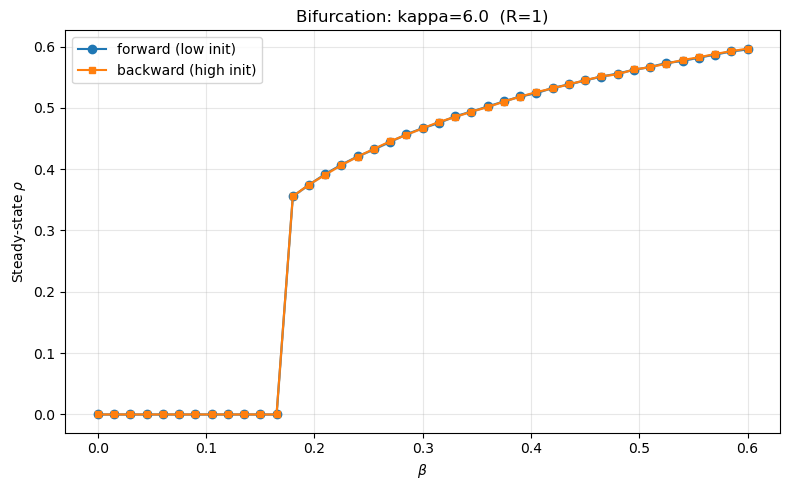

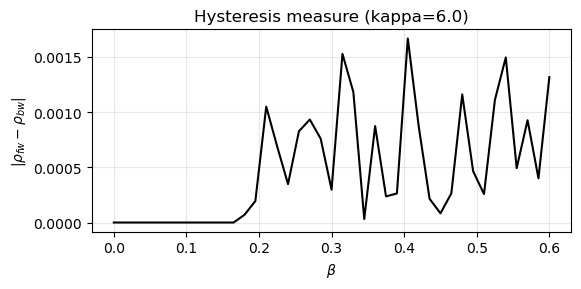

All kappas done. Total time: 58.3s


In [14]:
#!/usr/bin/env python3
# hyper_mmca_bifurcation_kappa6_9.py
"""
Bifurcation / hysteresis experiment (MMCA + Theta) for 3-uniform hypergraphs.
Produces forward/backward steady-state rho(beta) curves for specified kappas.

How to use:
    - Edit PARAMETERS below (n, kappas, BETAS, R_graphs, warm_start, reuse_same_graph...)
    - Run: python hyper_mmca_bifurcation_kappa6_9.py
Outputs:
    - PNG figures (bifurcation plots) and CSV summaries in OUT_DIR
    - CSVs: mean/std arrays and raw runs matrices (per kappa)
"""

import os
import time
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------- Hypergraph generator ---------------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    """Generate random 3-uniform hypergraph H(n,m,3) by sampling distinct triples until m reached."""
    if seed is not None:
        rng = np.random.RandomState(seed)
    else:
        rng = np.random
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    # batch-sampling to speed up
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        # ensure each row has distinct nodes; resample if needed
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# --------------------------- MMCA model class ---------------------------
class HyperSISModel:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0]
        self.edge_j = self.hyperedges[:,1]
        self.edge_k = self.hyperedges[:,2]
        # node -> list of incident (edge_idx, position)
        self.node_edge_pos = [[] for _ in range(self.n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def _update_theta_from_p(self, p, Theta, eta, gamma):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        Theta_new = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        return np.clip(Theta_new, 0.0, 1.0), Phi

    def mmca_step(self, p, Theta, beta_d, mu, eta, gamma):
        """One MMCA step: compute Q for each node, p_next, Theta_next, Phi_edges."""
        prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
        Q = np.ones(self.n, dtype=float)
        # per-node accumulation (could vectorize further, but clarity)
        for node in range(self.n):
            prod_val = 1.0
            for (ei, pos) in self.node_edge_pos[node]:
                if pos == 0:
                    prod_oth = prod_pos0[ei]
                elif pos == 1:
                    prod_oth = prod_pos1[ei]
                else:
                    prod_oth = prod_pos2[ei]
                prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
            Q[node] = prod_val
        p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
        Theta_next, Phi = self._update_theta_from_p(p, Theta, eta, gamma)
        return p_next, Theta_next, Q, Phi

    def run_mmca_until_converged(self, beta_d, mu, eta, gamma,
                                 rho0=0.01, Theta0=1.0,
                                 tol=1e-8, max_iter=2000, record_traj=False):
        """
        Iterate MMCA starting from uniform p_i(0)=rho0 and Theta_e(0)=Theta0 until convergence.
        Returns steady_rho, steady_Theta_mean, (optional trajectories), iters.
        这个方法通过迭代MMCA方程，直到系统达到稳态（收敛）。
        """
        p = np.full(self.n, float(rho0), dtype=float)
        Theta = np.full(self.m, float(Theta0), dtype=float)

        # 记录初始状态
        if record_traj:
            rho_hist = [p.mean()]
            theta_hist = [Theta.mean()]

        for it in range(max_iter):
            # a. 执行单步MMCA更新
            p_next, Theta_next, Q, Phi = self.mmca_step(p, Theta, beta_d, mu, eta, gamma)
            # b. 计算变化量（收敛判据）
            dp = np.max(np.abs(p_next - p))    # 节点概率最大变化
            dTheta = np.max(np.abs(Theta_next - Theta))  # 活跃度最大变化
            # c. 更新状态
            p, Theta = p_next, Theta_next

            # 每次迭代记录平均值
            if record_traj:
                rho_hist.append(p.mean())    # 记录感染比例演化
                theta_hist.append(Theta.mean())  # 记录活跃度演化

            # d. 收敛检查
            if dp < tol and dTheta < tol:
                break
        if record_traj:
            # 完整轨迹返回
            return p.mean(), Theta.mean(), np.array(rho_hist), np.array(theta_hist), int(it+1)
        else:
            return p.mean(), Theta.mean(), int(it+1)

# --------------------------- PARAMETERS (edit here) ---------------------------
n = 1500
KAPPAS = [6.0]         # the two kappas you asked
MU = 0.1
ETA = 0.6
GAMMA = 0.02

# Beta grid for bifurcation plot
beta_min = 0.0
beta_max = 0.6
beta_steps = 41
BETAS = np.linspace(beta_min, beta_max, beta_steps)

# forward/backward initial seeds
rho0_small = 0.09   # small seed for forward
rho0_large = 0.5    # large seed for backward

# MMCA solver params
TOL = 1e-7
MAX_ITERS = 1000
record_traj_example = False  # set True to keep example time series

# repeats & graph choices
R_graphs = 1           # repeats per kappa (set 20 for decent averaging)
reuse_same_graph = False  # if True, use same hypergraph for all betas per replicate
warm_start = True        # if True, warm-start each next beta from previous steady (helps tracking branches)

# randomization
SEED_BASE = 12345

# outputs
OUT_DIR = "out_bifurcation"
os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------- sweep function ---------------------------
def sweep_bifurcation_for_kappa(n, kappa, betas, mu, eta, gamma,
                                rho0_small, rho0_large, tol, max_iter,
                                R_graphs=10, reuse_same_graph=False, warm_start=True, seed_base=12345):
    """
    For a given kappa, run R_graphs independent replicates.
    Returns:
      forward_runs: shape (R_graphs, len(betas))
      backward_runs: shape (R_graphs, len(betas))
      times_taken: list per replicate
    """
    forward_runs = np.zeros((R_graphs, len(betas)), dtype=float)
    backward_runs = np.zeros((R_graphs, len(betas)), dtype=float)
    times_taken = []

    for r in range(R_graphs):
        t0 = time.time()
        gen_seed = None if seed_base is None else (seed_base + r)
        if reuse_same_graph:
            # 整个重复实验使用同一个超图
            hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=gen_seed)
            model = HyperSISModel(hyperedges, n)
        # forward scan 前向扫描：从小初始值开始
        prev_p_mean = None
        prev_theta_mean = None
        for i, beta in enumerate(betas):
            if not reuse_same_graph:
                hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=(None if gen_seed is None else gen_seed + i))
                model = HyperSISModel(hyperedges, n)
            # decide initial rho0 for this beta
            if warm_start and (i > 0):
                # warm-start using previous mean as uniform init (effective heuristic)
                # 第一次迭代 (i=0)：使用 rho0_small = 1e-3
                # 后续迭代 (i>0)：使用前一个β的稳态值 prev_p_mean
                rho0 = float(max(rho0_small, prev_p_mean))
            else:
                rho0 = rho0_small   # 1e-3

            steady_rho, steady_theta_mean, iters = model.run_mmca_until_converged(
                beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                rho0=rho0, Theta0=1.0, tol=tol, max_iter=max_iter, record_traj=False
            )
            forward_runs[r, i] = steady_rho
            prev_p_mean = steady_rho
            prev_theta_mean = steady_theta_mean

        # backward scan on (same/different) graphs 后向扫描：从大初始值开始
        prev_p_mean = None
        prev_theta_mean = None
        for j, beta in enumerate(betas[::-1]):
            idx = len(betas)-1 - j   # 计算正向索引
            if not reuse_same_graph:
                # if we used distinct graphs in forward, regenerate corresponding graph (or a new one)
                hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=(None if gen_seed is None else gen_seed + idx + 10000))
                model = HyperSISModel(hyperedges, n)

            #热启动的逻辑：
            # 第一次迭代 (j=0)：使用 rho0_large = 0.5
            # 后续迭代 (j>0)：使用前一个β的稳态值 prev_p_mean
            # 保护机制：min(1.0, prev_p_mean) 确保不会超过最大可能值
            if warm_start and (j > 0):
                rho0 = float(min(1.0, prev_p_mean))
            else:
                rho0 = rho0_large  # 0.5
            steady_rho, steady_theta_mean, iters = model.run_mmca_until_converged(
                beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                rho0=rho0, Theta0=1.0, tol=tol, max_iter=max_iter, record_traj=False
            )
            backward_runs[r, idx] = steady_rho
            prev_p_mean = steady_rho
            prev_theta_mean = steady_theta_mean

        times_taken.append(time.time() - t0)
        print(f"[kappa={kappa}] replicate {r+1}/{R_graphs} done, time {times_taken[-1]:.1f}s")

    return forward_runs, backward_runs, times_taken

# --------------------------- run for each kappa and plot ---------------------------
start_all = time.time()
for kappa in KAPPAS:
    print(f"\n=== Running bifurcation sweep for kappa = {kappa}  (R={R_graphs}) ===")
    f_runs, b_runs, times = sweep_bifurcation_for_kappa(
        n=n, kappa=kappa, betas=BETAS, mu=MU, eta=ETA, gamma=GAMMA,
        rho0_small=rho0_small, rho0_large=rho0_large,
        tol=TOL, max_iter=MAX_ITERS,
        R_graphs=R_graphs, reuse_same_graph=reuse_same_graph, warm_start=warm_start, seed_base=SEED_BASE
    )

    mean_f = f_runs.mean(axis=0); std_f = f_runs.std(axis=0)
    mean_b = b_runs.mean(axis=0); std_b = b_runs.std(axis=0)

    # save summary CSV + raw runs
    summary_df = pd.DataFrame({
        'beta': BETAS,
        'mean_forward': mean_f,
        'std_forward': std_f,
        'mean_backward': mean_b,
        'std_backward': std_b
    })
    runs_f_df = pd.DataFrame(f_runs, columns=[f'beta_{i:03d}' for i in range(len(BETAS))])
    runs_b_df = pd.DataFrame(b_runs, columns=[f'beta_{i:03d}' for i in range(len(BETAS))])

    prefix = f"kappa{int(kappa)}"
    summary_fn = os.path.join(OUT_DIR, f"{prefix}_bifurcation_summary.csv")
    runs_f_fn = os.path.join(OUT_DIR, f"{prefix}_forward_runs.csv")
    runs_b_fn = os.path.join(OUT_DIR, f"{prefix}_backward_runs.csv")
    summary_df.to_csv(summary_fn, index=False, float_format="%.6f")
    runs_f_df.to_csv(runs_f_fn, index=False, float_format="%.6f")
    runs_b_df.to_csv(runs_b_fn, index=False, float_format="%.6f")
    print(f"Saved summary and runs CSVs for kappa={kappa} to {OUT_DIR}")

    # plotting
    plt.figure(figsize=(8,5))
    plt.fill_between(BETAS, mean_f - std_f, mean_f + std_f, color='C0', alpha=0.2)
    plt.plot(BETAS, mean_f, '-o', color='C0', label='forward (low init)')
    plt.fill_between(BETAS, mean_b - std_b, mean_b + std_b, color='C1', alpha=0.2)
    plt.plot(BETAS, mean_b, '-s', color='C1', label='backward (high init)', markersize=4)
    plt.xlabel(r'$\beta$'); plt.ylabel(r'Steady-state $\rho$')
    plt.title(f'Bifurcation: kappa={kappa}  (R={R_graphs})')
    plt.legend()
    plt.grid(alpha=0.3) 
    plt.tight_layout()
    figfn = os.path.join(OUT_DIR, f"{prefix}_bifurcation.png")
    # plt.savefig(figfn, dpi=300)
    plt.show()

    # hysteresis measure plot
    diff = np.abs(mean_f - mean_b)
    plt.figure(figsize=(6,3))
    plt.plot(BETAS, diff, '-k')
    plt.xlabel(r'$\beta$'); plt.ylabel(r'$|\rho_{fw}-\rho_{bw}|$')
    plt.title(f'Hysteresis measure (kappa={kappa})')
    plt.grid(alpha=0.3); plt.tight_layout()
    figfn2 = os.path.join(OUT_DIR, f"{prefix}_hysteresis_diff.png")
    # plt.savefig(figfn2, dpi=300)
    plt.show()

print("All kappas done. Total time: {:.1f}s".format(time.time() - start_all))
